# 📏 Clase 4 — Medidas de dispersión y conceptos de muestreo
## Fundamentos de análisis exploratorio y estadística descriptiva

**Situación:** La empresa **ExpressLog** declara un promedio de 48 horas de entrega, pero recibe constantes quejas. El promedio no refleja toda la realidad. Necesitas medidas que describan la **variabilidad** del servicio.

**Objetivos:**
- Calcular e interpretar **rango**, **varianza** y **desviación estándar**
- Distinguir cálculos **poblacionales** vs **muestrales** (corrección de Bessel)
- Visualizar dispersión con bandas `±1σ` sobre histograma
- Comparar grupos con distintas variabilidades
- Decidir cuándo el promedio es o no representativo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')
print(f'numpy {np.__version__} | pandas {pd.__version__}')

✅ Librerías cargadas
numpy 2.4.6 | pandas 3.0.3


---
## PARTE 1 — Concepto de dispersión

### 1.1 La misma media, distintas historias

In [2]:
# Ejemplo exacto de la presentación
A = pd.Series([10, 10, 10])   # sin variabilidad
B = pd.Series([5, 10, 15])    # con variabilidad

print(f'Dataset A: {A.values}  → Media: {A.mean()} | Rango: {A.max()-A.min()} | Desv.Std: {A.std(ddof=1):.2f}')
print(f'Dataset B: {B.values} → Media: {B.mean()} | Rango: {B.max()-B.min()} | Desv.Std: {B.std(ddof=1):.2f}')
print()
print('Misma media (10), diferente dispersión. Sin medidas de dispersión los datasets parecen idénticos.')

Dataset A: [10 10 10]  → Media: 10.0 | Rango: 0 | Desv.Std: 0.00
Dataset B: [ 5 10 15] → Media: 10.0 | Rango: 10 | Desv.Std: 5.00

Misma media (10), diferente dispersión. Sin medidas de dispersión los datasets parecen idénticos.


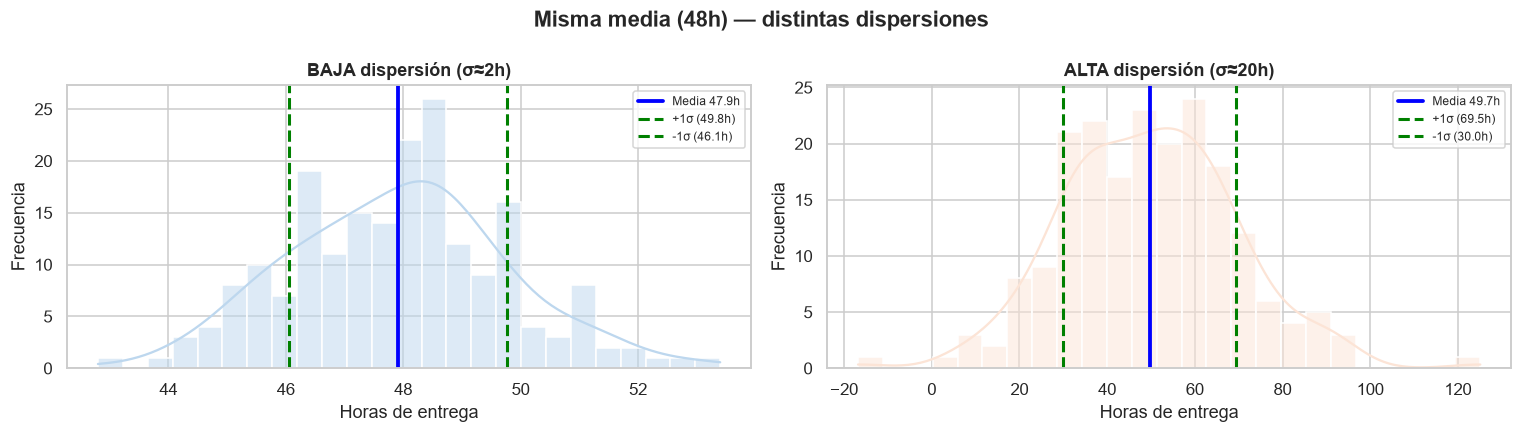

In [3]:
# Demostración ampliada con distribuciones reales
np.random.seed(42)
baja_disp  = pd.Series(np.random.normal(48, 2,  200).round(1))  # desv=2h
alta_disp  = pd.Series(np.random.normal(48, 20, 200).round(1))  # desv=20h

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Misma media (48h) — distintas dispersiones', fontweight='bold')

for ax, datos, titulo, color in zip(
    axes,
    [baja_disp, alta_disp],
    ['BAJA dispersión (σ≈2h)', 'ALTA dispersión (σ≈20h)'],
    ['#BDD7EE', '#FCE4D6']
):
    m = datos.mean()
    s = datos.std(ddof=1)
    sns.histplot(datos, bins=25, kde=True, ax=ax, color=color, edgecolor='white')
    ax.axvline(m,   color='blue',  linewidth=2.5, label=f'Media {m:.1f}h')
    ax.axvline(m+s, color='green', linestyle='--', linewidth=2, label=f'+1σ ({m+s:.1f}h)')
    ax.axvline(m-s, color='green', linestyle='--', linewidth=2, label=f'-1σ ({m-s:.1f}h)')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Horas de entrega')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### ✏️ Ejercicio 1.1 — Reflexiona:

In [4]:
# ✏️ ¿Por qué el promedio solo no es suficiente para evaluar la calidad de un servicio?
r1 = ""

# ✏️ ¿En qué situación de tu contexto laboral sería importante medir la dispersión?
r2 = ""

# ✏️ Con alta dispersión en tiempos de entrega, ¿qué problemas operacionales podrían ocurrir?
r3 = ""

print(f'1. {r1}')
print(f'2. {r2}')
print(f'3. {r3}')

1. 
2. 
3. 


---
## PARTE 2 — Las tres medidas de dispersión

### 2.1 Rango: la medida más simple

In [5]:
# Ejemplo exacto de la presentación
valores = pd.Series([8, 11, 9, 5, 13, 7, 10])

rango = valores.max() - valores.min()
print(f'Serie: {valores.values}')
print(f'Máximo: {valores.max()} | Mínimo: {valores.min()}')
print(f'Rango = {valores.max()} - {valores.min()} = {rango}')
print()
print('Interpretación: todos los valores se distribuyen dentro de una ventana de 8 unidades.')

Serie: [ 8 11  9  5 13  7 10]
Máximo: 13 | Mínimo: 5
Rango = 13 - 5 = 8

Interpretación: todos los valores se distribuyen dentro de una ventana de 8 unidades.


In [6]:
# Demostración de la limitación del rango ante outliers
sin_outlier = pd.Series([2, 3, 3, 4, 4, 4, 4, 3, 3, 2])   # rango 2
con_outlier = pd.Series([2, 3, 3, 4, 4, 4, 4, 3, 3, 18])  # rango 16

print('Sin outlier:')
print(f'  Valores: {sin_outlier.values}')
print(f'  Rango: {sin_outlier.max()-sin_outlier.min()} | Media: {sin_outlier.mean():.1f}')
print()
print('Con outlier (18 en lugar del último 2):')
print(f'  Valores: {con_outlier.values}')
print(f'  Rango: {con_outlier.max()-con_outlier.min()} | Media: {con_outlier.mean():.1f}')
print()
print('⚠️  El rango pasó de 2 a 16 por un solo valor extremo.')
print('   Por eso el rango no debe usarse como única medida de dispersión.')

Sin outlier:
  Valores: [2 3 3 4 4 4 4 3 3 2]
  Rango: 2 | Media: 3.2

Con outlier (18 en lugar del último 2):
  Valores: [ 2  3  3  4  4  4  4  3  3 18]
  Rango: 16 | Media: 4.8

⚠️  El rango pasó de 2 a 16 por un solo valor extremo.
   Por eso el rango no debe usarse como única medida de dispersión.


### 2.2 Varianza: dispersión promedio al cuadrado

In [7]:
# Ejemplo exacto de la presentación
valores_np = np.array([4, 8, 6, 5, 10])
media = np.mean(valores_np)

var_poblacional = np.var(valores_np, ddof=0)
var_muestral    = np.var(valores_np, ddof=1)

print(f'Valores: {valores_np}')
print(f'Media:   {media}')
print()
print(f'Varianza poblacional (ddof=0): {var_poblacional:.4f}')
print(f'Varianza muestral    (ddof=1): {var_muestral:.4f}')
print()

# Mostrar el cálculo paso a paso
diferencias = valores_np - media
cuadrados   = diferencias ** 2
print('Cálculo paso a paso:')
print(f'  Diferencias (xi - media): {diferencias}')
print(f'  Cuadrados (xi - media)²:  {cuadrados}')
print(f'  Suma de cuadrados:        {cuadrados.sum()}')
print(f'  Dividido n   (población): {cuadrados.sum()/len(valores_np):.4f}')
print(f'  Dividido n-1 (muestra):   {cuadrados.sum()/(len(valores_np)-1):.4f}')

Valores: [ 4  8  6  5 10]
Media:   6.6

Varianza poblacional (ddof=0): 4.6400
Varianza muestral    (ddof=1): 5.8000

Cálculo paso a paso:
  Diferencias (xi - media): [-2.6  1.4 -0.6 -1.6  3.4]
  Cuadrados (xi - media)²:  [ 6.76  1.96  0.36  2.56 11.56]
  Suma de cuadrados:        23.2
  Dividido n   (población): 4.6400
  Dividido n-1 (muestra):   5.8000


### 2.3 Desviación estándar: dispersión en las mismas unidades

In [8]:
desv_est_pobl = np.std(valores_np, ddof=0)
desv_est_mues = np.std(valores_np, ddof=1)

print(f'Desviación estándar poblacional (ddof=0): {desv_est_pobl:.4f}')
print(f'Desviación estándar muestral    (ddof=1): {desv_est_mues:.4f}')
print()
print(f'√ de varianza muestral: {np.sqrt(var_muestral):.4f}  ← igual a desv.std muestral ✅')
print()
print('Interpretación:')
print(f'  Media = {media:.1f}')
print(f'  La mayoría de los valores está entre {media - desv_est_mues:.1f} y {media + desv_est_mues:.1f}')
print(f'  Rango ±1σ representa ~68% de los datos en distribución normal')

Desviación estándar poblacional (ddof=0): 2.1541
Desviación estándar muestral    (ddof=1): 2.4083

√ de varianza muestral: 2.4083  ← igual a desv.std muestral ✅

Interpretación:
  Media = 6.6
  La mayoría de los valores está entre 4.2 y 9.0
  Rango ±1σ representa ~68% de los datos en distribución normal


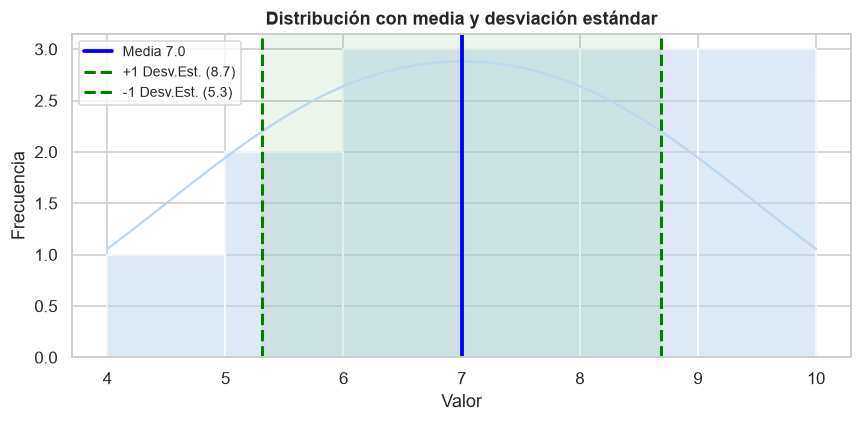

In [9]:
# Visualización de la presentación: histograma con media y ±1 desv.std
datos_vis = np.array([4, 8, 6, 5, 10, 7, 9, 6, 8, 5, 7, 9, 6, 8, 7])
m_vis = np.mean(datos_vis)
s_vis = np.std(datos_vis, ddof=1)

plt.figure(figsize=(8, 4))
sns.histplot(datos_vis, kde=True, bins=6, color='#BDD7EE', edgecolor='white')
plt.axvline(m_vis,       color='blue',  linewidth=2.5,  label=f'Media {m_vis:.1f}')
plt.axvline(m_vis + s_vis, color='green', linestyle='--', linewidth=2,
            label=f'+1 Desv.Est. ({m_vis+s_vis:.1f})')
plt.axvline(m_vis - s_vis, color='green', linestyle='--', linewidth=2,
            label=f'-1 Desv.Est. ({m_vis-s_vis:.1f})')
plt.axvspan(m_vis - s_vis, m_vis + s_vis, alpha=0.08, color='green')
plt.legend(fontsize=9)
plt.title('Distribución con media y desviación estándar', fontweight='bold')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### ✏️ Ejercicio 2 — Completa:

In [10]:
ventas = np.array([80, 82, 81, 150, 79, 83, 80, 85, 78, 82])

# ✏️ Calcula rango, varianza muestral y desviación estándar muestral:
rango_v  = ???
var_v    = np.var(ventas, ddof=???)
desv_v   = np.std(ventas, ddof=???)
media_v  = np.mean(ventas)

print(f'Media:           {media_v:.2f} unidades')
print(f'Rango:           {rango_v}')
print(f'Varianza:        {var_v:.2f}')
print(f'Desv. estándar:  {desv_v:.2f}')

# ✏️ ¿El valor 150 parece coherente? ¿Cómo afecta a la media y a la desv.std?
r_ventas = ""

# ✏️ ¿Qué pasaría si elimináramos el 150 del análisis?
sin_outlier_v = ventas[ventas != 150]
print(f'\nSin outlier → Media: {sin_outlier_v.mean():.2f} | Desv.std: {sin_outlier_v.std(ddof=1):.2f}')
print('Respuesta:', r_ventas)

SyntaxError: invalid syntax (838185080.py, line 4)

---
## PARTE 3 — Población, muestra y corrección de Bessel

### 3.1 ¿Por qué importa la diferencia?

In [11]:
# Demostración con tabla comparativa
datos_demo = np.array([4, 8, 6, 5, 10])
n = len(datos_demo)

tabla_bessel = pd.DataFrame({
    'Fórmula': ['Var poblacional (÷n)', 'Var muestral (÷n-1)', 'Desv.Std pobl.', 'Desv.Std muestral'],
    'ddof': [0, 1, 0, 1],
    'Denominador': [n, n-1, n, n-1],
    'Resultado': [
        np.var(datos_demo, ddof=0),
        np.var(datos_demo, ddof=1),
        np.std(datos_demo, ddof=0),
        np.std(datos_demo, ddof=1)
    ],
    'Función Python': [
        'np.var(x, ddof=0)',
        'np.var(x, ddof=1)',
        'np.std(x, ddof=0)',
        'np.std(x, ddof=1)'
    ]
})
tabla_bessel['Resultado'] = tabla_bessel['Resultado'].round(4)
print('=== Corrección de Bessel: ddof=0 (población) vs ddof=1 (muestra) ===')
print(tabla_bessel.to_string(index=False))

=== Corrección de Bessel: ddof=0 (población) vs ddof=1 (muestra) ===
             Fórmula  ddof  Denominador  Resultado    Función Python
Var poblacional (÷n)     0            5     4.6400 np.var(x, ddof=0)
 Var muestral (÷n-1)     1            4     5.8000 np.var(x, ddof=1)
      Desv.Std pobl.     0            5     2.1541 np.std(x, ddof=0)
   Desv.Std muestral     1            4     2.4083 np.std(x, ddof=1)


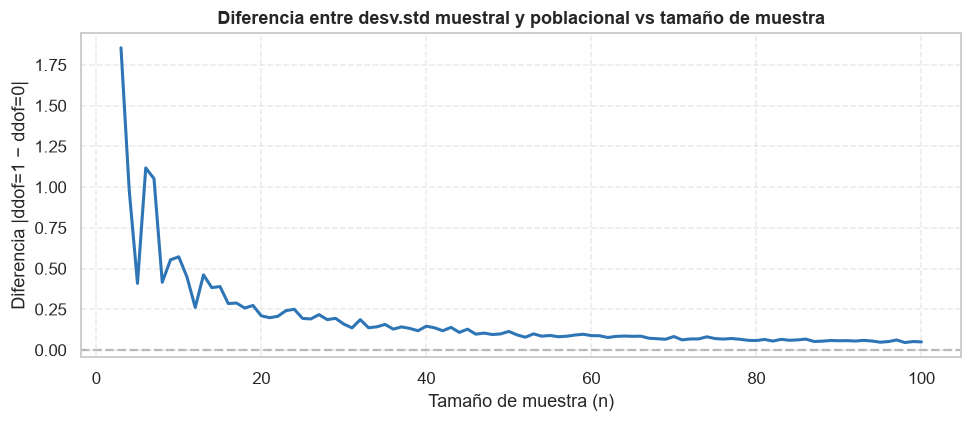

→ A mayor tamaño de muestra, menor diferencia entre ambas fórmulas.


In [12]:
# Visualizar el impacto de Bessel en función del tamaño de muestra
tamanios = range(3, 101)
np.random.seed(42)
poblacion_real = np.random.normal(50, 10, 10000)  # población real, σ=10

diffs = []
for n_s in tamanios:
    muestra = np.random.choice(poblacion_real, size=n_s, replace=False)
    diff = abs(np.std(muestra, ddof=1) - np.std(muestra, ddof=0))
    diffs.append(diff)

plt.figure(figsize=(9, 4))
plt.plot(list(tamanios), diffs, color='#2E75B6', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Diferencia entre desv.std muestral y poblacional vs tamaño de muestra',
          fontweight='bold')
plt.xlabel('Tamaño de muestra (n)')
plt.ylabel('Diferencia |ddof=1 − ddof=0|')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print('→ A mayor tamaño de muestra, menor diferencia entre ambas fórmulas.')

### ✏️ Ejercicio 3 — Responde:

In [13]:
# ✏️ ¿Cuándo usarías ddof=0 y cuándo ddof=1?
r_ddof = ""

# ✏️ ¿Por qué en ciencia de datos casi siempre usamos ddof=1?
r_bessel = ""

# ✏️ ¿Qué error se comete si usas ddof=0 con datos muestrales?
r_error = ""

print('ddof=0 vs ddof=1:', r_ddof)
print('Por qué ddof=1:  ', r_bessel)
print('Error ddof=0:    ', r_error)

ddof=0 vs ddof=1: 
Por qué ddof=1:   
Error ddof=0:     


---
## PARTE 4 — Actividad guiada: ExpressLog

### 4.1 Cargar y explorar el dataset

In [14]:
df = pd.read_csv('entregas_express.csv')

print(f'Registros: {len(df)}')
print()
print(df.head(8))
print()
print('=== Resumen estadístico ===')
print(df['tiempo_entrega'].describe().round(2))

Registros: 80

  id_pedido  tiempo_entrega         region       canal categoria_producto
0      P001              40    Antofagasta  Telefónico            Muebles
1      P002              40      Los Lagos    Sucursal               Ropa
2      P003              49  Metropolitana  Telefónico               Ropa
3      P004              51  Metropolitana         App        Electrónica
4      P005              62    Antofagasta    Sucursal          Alimentos
5      P006              40     Valparaíso  Telefónico            Muebles
6      P007             117     Valparaíso    Sucursal               Ropa
7      P008              55     Valparaíso         App          Alimentos

=== Resumen estadístico ===
count     80.00
mean      48.40
std       21.74
min       22.00
25%       36.00
50%       43.50
75%       52.50
max      122.00
Name: tiempo_entrega, dtype: float64


### 4.2 Calcular rango, varianza y desviación estándar

In [15]:
datos = df['tiempo_entrega']

rango           = datos.max() - datos.min()
var_poblacional = np.var(datos, ddof=0)
var_muestral    = np.var(datos, ddof=1)
desv_est        = np.std(datos, ddof=1)
media           = np.mean(datos)

print('=== Medidas de dispersión — Tiempos de entrega (horas) ===')
print(f'  Media:                   {media:.2f} h')
print(f'  Rango:                   {rango} h')
print(f'  Varianza poblacional:    {var_poblacional:.2f} h²')
print(f'  Varianza muestral:       {var_muestral:.2f} h²')
print(f'  Desv. estándar muestral: {desv_est:.2f} h')
print()
print(f'  Rango ±1σ: [{media-desv_est:.1f}h — {media+desv_est:.1f}h]')
pct_dentro = ((datos >= media-desv_est) & (datos <= media+desv_est)).mean() * 100
print(f'  % de pedidos dentro de ±1σ: {pct_dentro:.1f}%')

=== Medidas de dispersión — Tiempos de entrega (horas) ===
  Media:                   48.40 h
  Rango:                   100 h
  Varianza poblacional:    466.89 h²
  Varianza muestral:       472.80 h²
  Desv. estándar muestral: 21.74 h

  Rango ±1σ: [26.7h — 70.1h]
  % de pedidos dentro de ±1σ: 82.5%


### 4.3 Visualización con media y ±1σ

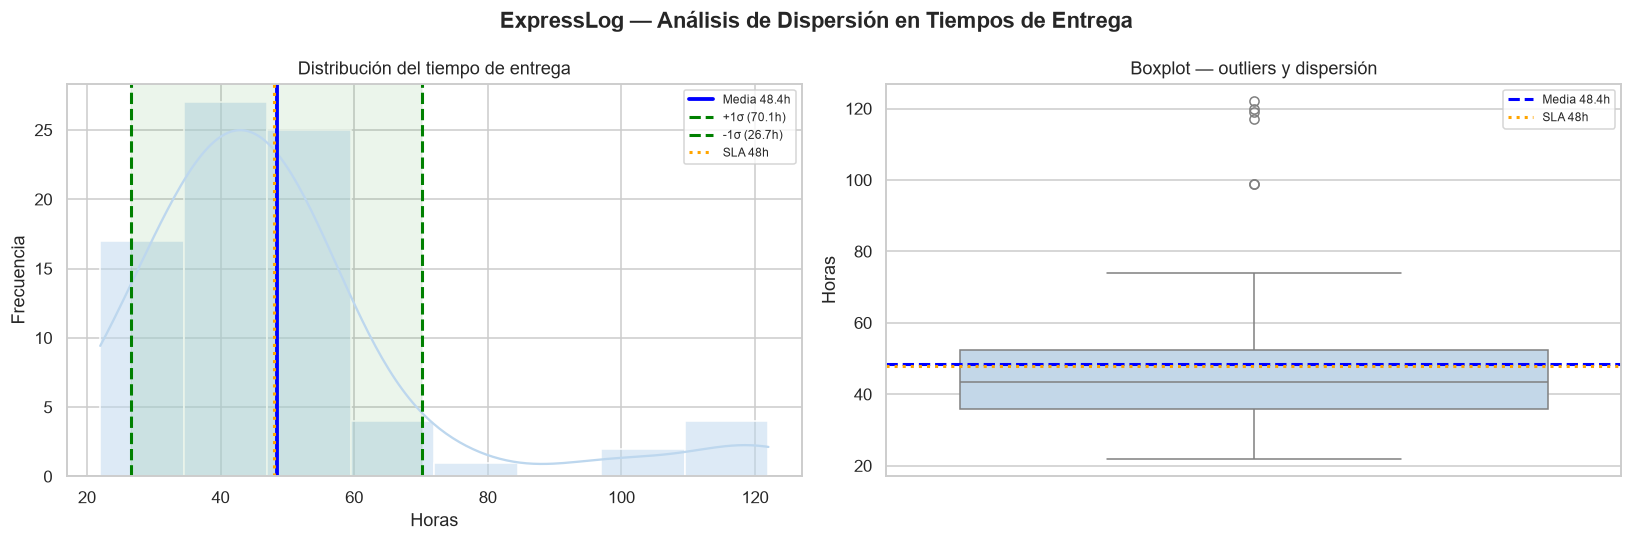

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ExpressLog — Análisis de Dispersión en Tiempos de Entrega', fontweight='bold')

# Histograma + KDE con bandas
sns.histplot(datos, bins=8, kde=True, ax=axes[0], color='#BDD7EE', edgecolor='white')
axes[0].axvline(media,             color='blue',   linewidth=2.5,  label=f'Media {media:.1f}h')
axes[0].axvline(media + desv_est,  color='green',  linestyle='--', linewidth=2,
                label=f'+1σ ({media+desv_est:.1f}h)')
axes[0].axvline(media - desv_est,  color='green',  linestyle='--', linewidth=2,
                label=f'-1σ ({media-desv_est:.1f}h)')
axes[0].axvspan(media - desv_est, media + desv_est, alpha=0.08, color='green')
axes[0].axvline(48, color='orange', linestyle=':', linewidth=2, label='SLA 48h')
axes[0].set_title('Distribución del tiempo de entrega')
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)

# Boxplot + swarm
sns.boxplot(y=datos, ax=axes[1], color='#BDD7EE')
axes[1].axhline(media,   color='blue',  linestyle='--', linewidth=2, label=f'Media {media:.1f}h')
axes[1].axhline(48,      color='orange',linestyle=':',  linewidth=2, label='SLA 48h')
axes[1].set_title('Boxplot — outliers y dispersión')
axes[1].set_ylabel('Horas')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.4 Análisis por región

=== Dispersión por región (ordenada por desv.std) ===
               media  desv_std  rango   n  cv_pct
region                                           
Metropolitana  50.95     27.22    100  19    53.4
Biobío         46.95     24.61     98  19    52.4
Valparaíso     51.67     24.50     89  15    47.4
Los Lagos      46.55     16.99     51  11    36.5
Antofagasta    45.31      9.34     29  16    20.6

cv_pct = Coeficiente de Variación (%) = desv.std/media × 100
→ Mayor CV = mayor inconsistencia relativa del servicio


C:\Users\Natalie\AppData\Local\Temp\ipykernel_14160\2290770272.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='tiempo_entrega', order=orden, palette='Blues_r')


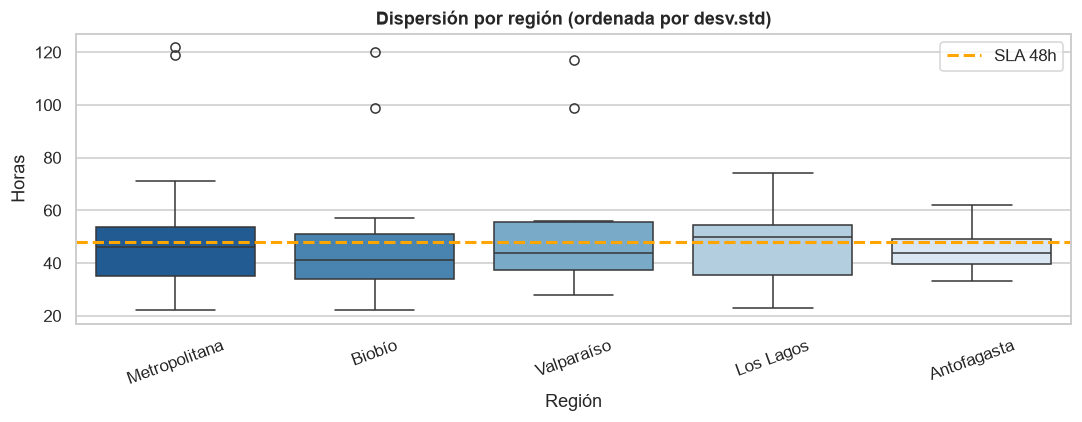

In [17]:
disp_region = df.groupby('region')['tiempo_entrega'].agg(
    media='mean',
    desv_std=lambda x: np.std(x, ddof=1),
    rango=lambda x: x.max() - x.min(),
    n='count'
).round(2)
disp_region['cv_pct'] = (disp_region['desv_std'] / disp_region['media'] * 100).round(1)
disp_region = disp_region.sort_values('desv_std', ascending=False)

print('=== Dispersión por región (ordenada por desv.std) ===')
print(disp_region.to_string())
print()
print('cv_pct = Coeficiente de Variación (%) = desv.std/media × 100')
print('→ Mayor CV = mayor inconsistencia relativa del servicio')

plt.figure(figsize=(10, 4))
orden = disp_region.index
sns.boxplot(data=df, x='region', y='tiempo_entrega', order=orden, palette='Blues_r')
plt.axhline(48, color='orange', linestyle='--', linewidth=2, label='SLA 48h')
plt.title('Dispersión por región (ordenada por desv.std)', fontweight='bold')
plt.xlabel('Región')
plt.ylabel('Horas')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

### ✏️ Ejercicio 4 — Concluye:

In [18]:
# ✏️ ¿Es el promedio de 48h representativo del servicio? ¿Por qué?
r_repr = ""

# ✏️ ¿Qué región tiene mayor inconsistencia en sus tiempos?
r_region = disp_region.index[0]   # modifica si quieres

# ✏️ ¿Qué acción operacional recomendarías basándote en la dispersión?
r_accion = ""

# ✏️ ¿Usarías varianza poblacional o muestral en este caso? ¿Por qué?
r_pob_mues = ""

print('--- CONCLUSIONES ACTIVIDAD GUIADA ---')
print(f'¿Promedio representativo? {r_repr}')
print(f'Región más inconsistente: {r_region}')
print(f'Acción recomendada:       {r_accion}')
print(f'Pobl. vs Muestral:        {r_pob_mues}')

--- CONCLUSIONES ACTIVIDAD GUIADA ---
¿Promedio representativo? 
Región más inconsistente: Metropolitana
Acción recomendada:       
Pobl. vs Muestral:        


---
## PARTE 5 — Actividad autónoma: Prueba técnica de diagnóstico

### 5.1 Cargar el dataset

In [22]:
df2  = pd.read_csv('calificaciones_autonomo.csv')
#calif = df2['calificaciones']

print(f'Registros: {len(df2)}')
print()
print(df2.head(8))
print()
print('=== Resumen estadístico ===')
#print(calif.describe().round(2))

Registros: 200

  id_encuesta       fecha     segmento       canal              producto  \
0        C001  2024-03-26  Empresarial  Telefónico       Telefonía Móvil   
1        C002  2024-05-01     Gobierno        Chat  Internet Empresarial   
2        C003  2024-04-25  Residencial  Presencial            Pack Combo   
3        C004  2024-04-25  Empresarial         Web        Internet Hogar   
4        C005  2024-01-16     Gobierno        Chat       Telefonía Móvil   
5        C006  2024-02-04  Residencial  Presencial        Internet Hogar   
6        C007  2024-05-16  Residencial  Telefónico  Internet Empresarial   
7        C008  2024-04-03  Empresarial         Web        Internet Hogar   

   calificacion  tiempo_resolucion_min  
0             7                      7  
1             7                     26  
2             3                     26  
3            10                     24  
4            10                     18  
5             8                      3  
6           

### 5.2 Calcular las medidas de dispersión

In [23]:
# Cargar dataset
df2  = pd.read_csv('calificaciones_autonomo.csv')

df2.head()

,id_encuesta,fecha,segmento,canal,producto,calificacion,tiempo_resolucion_min
0,C001,2024-03-26,Empresarial,Telefónico,Telefonía Móvil,7,7
1,C002,2024-05-01,Gobierno,Chat,Internet Empresarial,7,26
2,C003,2024-04-25,Residencial,Presencial,Pack Combo,3,26
3,C004,2024-04-25,Empresarial,Web,Internet Hogar,10,24
4,C005,2024-01-16,Gobierno,Chat,Telefonía Móvil,10,18


In [25]:
calif = df2['calificacion']

print(f'Registros: {len(df2)}')
print()
print(df2.head(8))
print()
print('=== Resumen estadístico ===')
print(calif.describe().round(2))

Registros: 200

  id_encuesta       fecha     segmento       canal              producto  \
0        C001  2024-03-26  Empresarial  Telefónico       Telefonía Móvil   
1        C002  2024-05-01     Gobierno        Chat  Internet Empresarial   
2        C003  2024-04-25  Residencial  Presencial            Pack Combo   
3        C004  2024-04-25  Empresarial         Web        Internet Hogar   
4        C005  2024-01-16     Gobierno        Chat       Telefonía Móvil   
5        C006  2024-02-04  Residencial  Presencial        Internet Hogar   
6        C007  2024-05-16  Residencial  Telefónico  Internet Empresarial   
7        C008  2024-04-03  Empresarial         Web        Internet Hogar   

   calificacion  tiempo_resolucion_min  
0             7                      7  
1             7                     26  
2             3                     26  
3            10                     24  
4            10                     18  
5             8                      3  
6           

In [26]:
media2        = np.mean(calif)
rango2        = calif.max() - calif.min()
var_muestra2  = np.var(calif, ddof=1)
var_pobl2     = np.var(calif, ddof=0)
desv_est2     = np.std(calif, ddof=1)

print('=== Medidas de dispersión — Calificaciones ===')
print(f'  Media:                   {media2:.2f}')
print(f'  Rango:                   {rango2:.1f}')
print(f'  Varianza poblacional:    {var_pobl2:.4f}')
print(f'  Varianza muestral:       {var_muestra2:.4f}')
print(f'  Desv. estándar muestral: {desv_est2:.4f}')
print()
print(f'  Rango ±1σ: [{media2-desv_est2:.2f} — {media2+desv_est2:.2f}]')

=== Medidas de dispersión — Calificaciones ===
  Media:                   6.96
  Rango:                   9.0
  Varianza poblacional:    4.7184
  Varianza muestral:       4.7421
  Desv. estándar muestral: 2.1776

  Rango ±1σ: [4.78 — 9.14]


### 5.3 Visualización

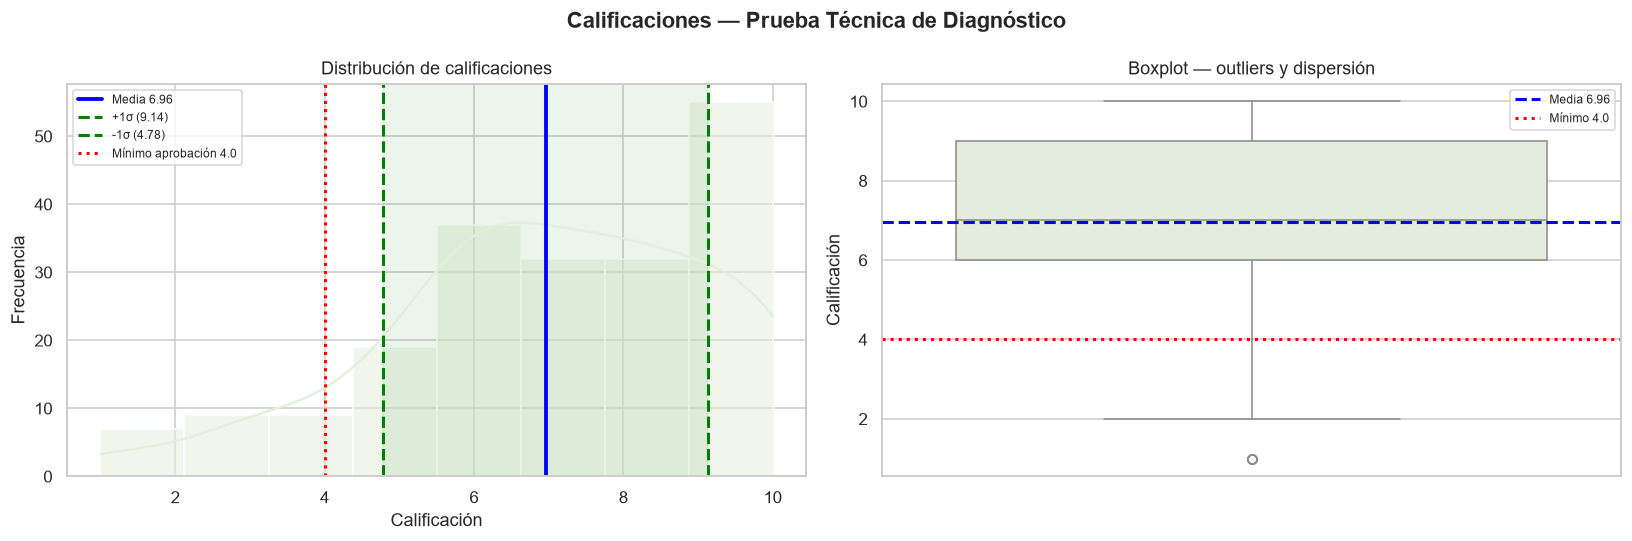

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Calificaciones — Prueba Técnica de Diagnóstico', fontweight='bold')

sns.histplot(calif, bins=8, kde=True, ax=axes[0], color='#E2EFDA', edgecolor='white')
axes[0].axvline(media2,              color='blue',  linewidth=2.5,  label=f'Media {media2:.2f}')
axes[0].axvline(media2 + desv_est2,  color='green', linestyle='--', linewidth=2,
                label=f'+1σ ({media2+desv_est2:.2f})')
axes[0].axvline(media2 - desv_est2,  color='green', linestyle='--', linewidth=2,
                label=f'-1σ ({media2-desv_est2:.2f})')
axes[0].axvline(4.0, color='red', linestyle=':', linewidth=2, label='Mínimo aprobación 4.0')
axes[0].axvspan(media2-desv_est2, media2+desv_est2, alpha=0.08, color='green')
axes[0].set_title('Distribución de calificaciones')
axes[0].set_xlabel('Calificación')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)

sns.boxplot(y=calif, ax=axes[1], color='#E2EFDA')
axes[1].axhline(media2, color='blue',  linestyle='--', linewidth=2, label=f'Media {media2:.2f}')
axes[1].axhline(4.0,    color='red',   linestyle=':',  linewidth=2, label='Mínimo 4.0')
axes[1].set_title('Boxplot — outliers y dispersión')
axes[1].set_ylabel('Calificación')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.4 Dispersión por módulo

=== Dispersión por módulo ===
             media  desv_std  rango   n
segmento                               
Empresarial  6.500     2.278      9  48
Pyme         7.213     2.245      9  47
Residencial  6.958     2.202      8  48
Gobierno     7.140     2.004      8  57


C:\Users\Natalie\AppData\Local\Temp\ipykernel_14160\1717073557.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='segmento', y='calificacion',


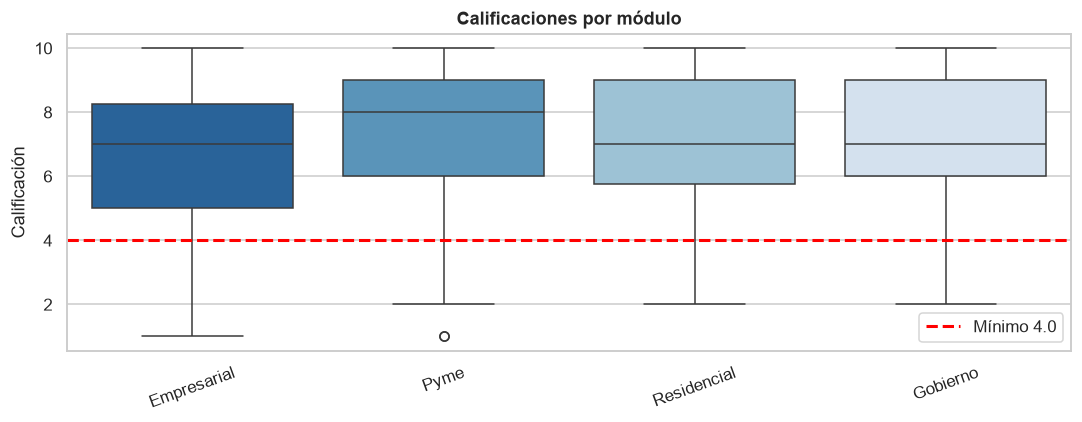

In [31]:
disp_modulo = df2.groupby('segmento')['calificacion'].agg(
    media='mean',
    desv_std=lambda x: np.std(x, ddof=1),
    rango=lambda x: x.max()-x.min(),
    n='count'
).round(3).sort_values('desv_std', ascending=False)

print('=== Dispersión por módulo ===')
print(disp_modulo.to_string())

plt.figure(figsize=(10, 4))
sns.boxplot(data=df2, x='segmento', y='calificacion',
            order=disp_modulo.index, palette='Blues_r')
plt.axhline(4.0, color='red', linestyle='--', linewidth=2, label='Mínimo 4.0')
plt.title('Calificaciones por módulo', fontweight='bold')
plt.xlabel('')
plt.ylabel('Calificación')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

### ✏️ Ejercicio 5 — Concluye:

In [32]:
# ✏️ ¿El promedio refleja con precisión el desempeño del grupo? ¿Por qué?
c1 = ""

# ✏️ ¿Hay alta variabilidad en las calificaciones? ¿Qué la indica?
c2 = ""

# ✏️ ¿Corresponde usar varianza muestral o poblacional aquí? Justifica.
c3 = ""

# ✏️ ¿Qué módulo presenta el rendimiento más irregular? ¿Qué harías al respecto?
c4 = ""

print('--- CONCLUSIONES ACTIVIDAD AUTÓNOMA ---')
for i, c in enumerate([c1, c2, c3, c4], 1):
    print(f'{i}. {c}')

--- CONCLUSIONES ACTIVIDAD AUTÓNOMA ---
1. 
2. 
3. 
4. 


---
## 📋 Resumen de funciones y buenas prácticas

| Medida | Función | ddof | Cuándo usarla |
|--------|---------|------|---------------|
| Rango | `max - min` | — | Vista rápida, complementar siempre |
| Varianza poblacional | `np.var(x, ddof=0)` | 0 | Tienes **toda** la población |
| Varianza muestral | `np.var(x, ddof=1)` | 1 | Trabajas con una **muestra** |
| Desv.std poblacional | `np.std(x, ddof=0)` | 0 | Tienes **toda** la población |
| Desv.std muestral | `np.std(x, ddof=1)` | 1 | Trabajas con una **muestra** |

**Señales de alerta en dispersión:**

| Situación | Qué indica | Acción |
|-----------|-----------|--------|
| Media ≠ Mediana (diferencia grande) | Sesgo + outliers | Usar mediana como valor típico |
| Desv.std > Media | Muy alta variabilidad | Revisar outliers, segmentar grupos |
| Rango muy grande, desv.std baja | Pocos outliers extremos | Tratar outliers por separado |
| Coeficiente de variación > 30% | Inconsistencia alta | Investigar causas de variabilidad |

> 💡 **Corrección de Bessel:** En ciencia de datos **casi siempre** usamos `ddof=1` porque trabajamos con muestras, no con poblaciones completas. Pandas `.std()` usa `ddof=1` por defecto.

> 💡 **Regla práctica:** Compara `desv.std / media × 100` (Coeficiente de Variación). Si supera el 30%, el promedio no representa bien al grupo.